# 🎥 Video 03: Molecular Sanitization, Cleaning & Quality Control
**RDKit Masterclass — From Zero to Drug Discovery AI**
* **Duration:** ~25 - 30 Minutes
* **Curriculum Level:** LEVEL 1 (Topic 07: Sanitization) & LEVEL 5 (Topics 26, 27, 28, 29)
* **Target Audience:** Cheminformatics Engineers, AI for Drug Discovery Researchers, Data Scientists

---

### ⏱️ Video Agenda & Timestamps
* **00:00 - 05:00** | What is Molecular Sanitization? The 8 Internal Steps
* **05:00 - 10:00** | Diagnosing Sanitization Failures (Valence errors, Aromaticity bugs)
* **10:00 - 14:30** | Debugging with `sanitize=False` and Manual Fixes
* **14:30 - 19:00** | Stripping Salts and Counterions with `SaltRemover`
* **19:00 - 23:30** | Deduplication & Resolving InChIKey Clashes
* **23:30 - 27:30** | Building an Automated Chemical Dataset Quality Control (QC) Pipeline
* **27:30 - 30:00** | Hands-On Exercise & Real Dataset Cleaning

---

### 🎯 Learning Objectives
1. Understand why RDKit rejects chemically unreasonable molecules.
2. Master the 8 sanitization operations: valence check, aromaticity perception, kekulization, etc.
3. Catch `Chem.MolSanitizeException` and debug broken molecules without crashing batch jobs.
4. Remove salts (HCl, TFA, sodium, acetate) to isolate the active pharmaceutical ingredient (API).
5. Build a production-grade QC report generator for chemical libraries.

In [1]:
# Step 0: Imports and Environment Setup
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw, SaltRemover
from rdkit.Chem.Draw import IPythonConsole
import pandas as pd

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (320, 220)

print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.6


## 1. What Happens During Sanitization?
When you call `Chem.MolFromSmiles(smi)`, RDKit by default calls `Chem.SanitizeMol(mol)`.
This executes an 8-step quality verification pipeline:
1. `SANITIZE_CLEANUP`: Cleans up non-standard representations.
2. `SANITIZE_PROPERTIES`: Calculates implicit valence and resets computed properties.
3. `SANITIZE_SYMMRINGS`: Finds symmetric rings.
4. `SANITIZE_KEKULIZE`: Checks if aromatic systems can be represented as valid Kekule structures.
5. `SANITIZE_SETCONJUGATION`: Identifies conjugated bonds.
6. `SANITIZE_SETHYBRIDIZATION`: Sets atom hybridization ($sp, sp^2, sp^3, sp^3d$).
7. `SANITIZE_CLEANUPCHIRALITY`: Removes invalid stereochemical flags.
8. `SANITIZE_ADJUSTHS`: Adds implicit hydrogens according to atomic valence rules.

In [2]:
# Normal sanitization in action
smi_good = "c1ccccc1O"  # Phenol
mol = Chem.MolFromSmiles(smi_good)
print("Phenol parsed and sanitized successfully!")
print(f"Oxygen hybridization: {mol.GetAtomWithIdx(6).GetHybridization()}")
print(f"Ring carbon aromaticity: {mol.GetAtomWithIdx(0).GetIsAromatic()}")

Phenol parsed and sanitized successfully!
Oxygen hybridization: SP2
Ring carbon aromaticity: True


## 2. Catching and Debugging Sanitization Failures
What happens when a chemist writes a 5-valent nitrogen without a formal positive charge? Or an unkekulizable aromatic ring?
RDKit fails with a `Chem.MolSanitizeException`.
Let's see how to inspect the raw molecule using `sanitize=False`!

In [3]:
# A classic error: uncharged pentavalent nitrogen in a nitro group: -N(=O)=O vs -[N+](=O)[O-]
broken_nitro_smiles = "CN(=O)=O"  # Chemically incorrect valence (5 bonds on uncharged N)

# Default attempt fails and returns None
mol_failed = Chem.MolFromSmiles(broken_nitro_smiles)
print(f"Default MolFromSmiles result: {mol_failed}")

# Load without sanitization to inspect what was in the string
mol_raw = Chem.MolFromSmiles(broken_nitro_smiles, sanitize=False)
print(f"Raw loaded molecule object: {mol_raw}")
print(f"Raw atoms count: {mol_raw.GetNumAtoms()}")

# Let's catch the exact sanitization error
try:
    Chem.SanitizeMol(mol_raw)
except Chem.MolSanitizeException as e:
    print(f"🚨 Caught Expected Sanitization Error:\n   {e}")

Default MolFromSmiles result: <rdkit.Chem.rdchem.Mol object at 0x798787451540>
Raw loaded molecule object: <rdkit.Chem.rdchem.Mol object at 0x798787451a80>
Raw atoms count: 4


## 3. Removing Salts and Solvents (`SaltRemover`)
In medicinal chemistry databases (e.g. ChEMBL, PubChem), molecules are often synthesized and crystallized as salts (e.g., Hydrochloride, Tartrate, Besylate, Sodium).
For molecular modeling, docking, QSAR, and ML, **we must remove salts** to retain only the parent active drug!

Stripped 'Metformin Hydrochloride': 10 atoms -> 9 atoms (Canonical: CN(C)C(=N)NC(=N)N)
Stripped 'Diclofenac Sodium': 20 atoms -> 19 atoms (Canonical: O=C([O-])Cc1ccccc1Nc1c(Cl)cccc1Cl)
Stripped 'Morphine Sulfate': 26 atoms -> 21 atoms (Canonical: CN1CCC23c4c5ccc(O)c4OC2C(O)C=CC3C1C5)


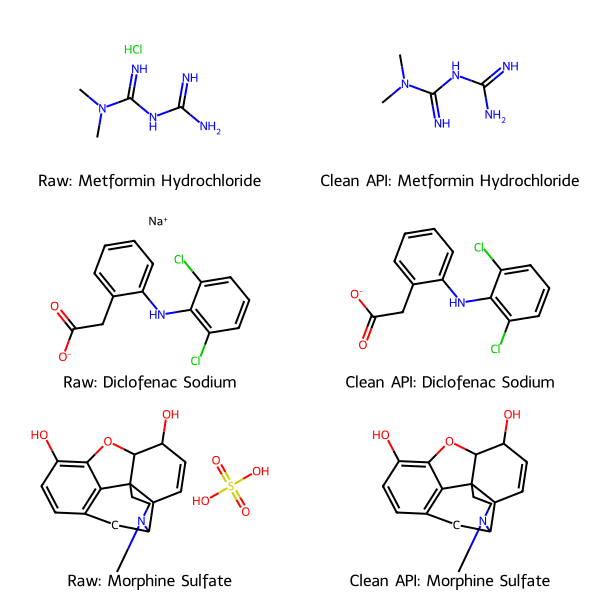

In [4]:
# Examples of drug molecules with salt adducts
salt_molecules = [
    ("Metformin Hydrochloride", "CN(C)C(=N)NC(=N)N.Cl"),
    ("Diclofenac Sodium", "O=C([O-])Cc1ccccc1Nc2c(Cl)cccc2Cl.[Na+]"),
    ("Morphine Sulfate", "CN1CCC23C4C1CC5=C2C(=C(C=C5)O)OC3C(C=C4)O.OS(=O)(=O)O")
]

# Initialize standard RDKit SaltRemover
remover = SaltRemover.SaltRemover()

cleaned_mols = []
legends = []

for name, smi in salt_molecules:
    m = Chem.MolFromSmiles(smi)
    # Strip salt
    m_clean = remover.StripMol(m)
    
    cleaned_mols.extend([m, m_clean])
    legends.extend([f"Raw: {name}", f"Clean API: {name}"])
    
    print(f"Stripped '{name}': {m.GetNumAtoms()} atoms -> {m_clean.GetNumAtoms()} atoms (Canonical: {Chem.MolToSmiles(m_clean)})")

Draw.MolsToGridImage(cleaned_mols, legends=legends, molsPerRow=2, subImgSize=(300, 200))

## 4. Alternative Fragment Splitting: Largest Fragment Chooser
Sometimes salts are unusual or not in the default dictionary. In that case, we can keep the largest organic fragment by molecular weight or heavy atom count.

In [5]:
def get_largest_fragment(mol):
    """Extract the largest covalent fragment from a multi-component Mol object."""
    frags = Chem.GetMolFrags(mol, asMols=True)
    if not frags:
        return None
    # Sort by number of heavy atoms descending
    sorted_frags = sorted(frags, key=lambda m: m.GetNumAtoms(), reverse=True)
    return sorted_frags[0]

test_smi = "CC(=O)O.Cc1ccc(cc1)S(=O)(=O)O.CN1CCN(CC1)c2ncnc3c2cc(OCC4CCCO4)c(OC)c3"
test_m = Chem.MolFromSmiles(test_smi)
parent_m = get_largest_fragment(test_m)

print(f"Original multi-component SMILES atoms: {test_m.GetNumAtoms()}")
print(f"Isolated parent API atoms:            {parent_m.GetNumAtoms()}")
print(f"Parent API SMILES:                    {Chem.MolToSmiles(parent_m)}")

Original multi-component SMILES atoms: 41
Isolated parent API atoms:            26
Parent API SMILES:                    COc1cc2ncnc(N3CCN(C)CC3)c2cc1OCC1CCCO1


## 5. Deduplication & InChIKey Hashes
Real datasets contain duplicate entries due to multiple assay reports, different salt forms, or varied drawing styles.
Using **Canonical SMILES** and **InChIKeys** provides an unambiguous deduplication filter.

In [6]:
# Dataset with duplicates in different drawing formats
raw_records = [
    {"id": "CMPD_1", "smiles": "c1ccccc1C(=O)O"},
    {"id": "CMPD_2", "smiles": "O=C(O)c1ccccc1"},                # Duplicate of 1
    {"id": "CMPD_3", "smiles": "c1ccccc1C(=O)O.Cl"},             # Salt duplicate of 1
    {"id": "CMPD_4", "smiles": "Cc1ccc(cc1)C(=O)O"},             # Distinct (4-methylbenzoic acid)
    {"id": "CMPD_5", "smiles": "Cc1cccc(c1)C(=O)O"},             # Distinct (3-methylbenzoic acid)
]

unique_dict = {}
remover = SaltRemover.SaltRemover()

for rec in raw_records:
    mol = Chem.MolFromSmiles(rec["smiles"])
    if mol is None:
        continue
    # Strip salts
    mol = remover.StripMol(mol)
    # Generate canonical InChIKey
    ikey = Chem.MolToInchiKey(mol)
    
    if ikey not in unique_dict:
        unique_dict[ikey] = {
            "ID": rec["id"],
            "Canonical_SMILES": Chem.MolToSmiles(mol),
            "InChIKey": ikey,
            "Count": 1
        }
    else:
        unique_dict[ikey]["Count"] += 1

df_unique = pd.DataFrame(list(unique_dict.values()))
print(f"Processed {len(raw_records)} records -> {len(df_unique)} unique compounds:")
display(df_unique)

Processed 5 records -> 3 unique compounds:


,ID,Canonical_SMILES,InChIKey,Count
0,CMPD_1,O=C(O)c1ccccc1,WPYMKLBDIGXBTP-UHFFFAOYSA-N,3
1,CMPD_4,Cc1ccc(C(=O)O)cc1,LPNBBFKOUUSUDB-UHFFFAOYSA-N,1
2,CMPD_5,Cc1cccc(C(=O)O)c1,GPSDUZXPYCFOSQ-UHFFFAOYSA-N,1


## 6. Building an Automated Chemical Dataset Quality Control (QC) Pipeline
Let's assemble a complete, production-grade dataset QC class that processes any CSV/dataframe of SMILES and produces a diagnostic health report.

In [7]:
class ChemicalDatasetQC:
    def __init__(self):
        self.salt_remover = SaltRemover.SaltRemover()
        
    def process_dataset(self, smiles_list):
        stats = {
            "total_input": len(smiles_list),
            "valid_mols": 0,
            "invalid_smiles": 0,
            "salts_removed": 0,
            "unique_compounds": 0,
            "duplicates": 0
        }
        
        seen_keys = set()
        curated_mols = []
        
        for smi in smiles_list:
            if not isinstance(smi, str) or not smi.strip():
                stats["invalid_smiles"] += 1
                continue
                
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                stats["invalid_smiles"] += 1
                continue
                
            stats["valid_mols"] += 1
            
            # Check for salts
            num_atoms_before = mol.GetNumAtoms()
            stripped = self.salt_remover.StripMol(mol)
            if stripped.GetNumAtoms() < num_atoms_before:
                stats["salts_removed"] += 1
            
            # Check uniqueness
            ikey = Chem.MolToInchiKey(stripped)
            if ikey in seen_keys:
                stats["duplicates"] += 1
            else:
                seen_keys.add(ikey)
                curated_mols.append(stripped)
                
        stats["unique_compounds"] = len(curated_mols)
        return stats, curated_mols

# Test our QC pipeline
test_dataset = [
    "CC(=O)Oc1ccccc1C(=O)O",         # Aspirin
    "CC(=O)Oc1ccccc1C(=O)O.Na",      # Aspirin Na
    "C1=CC=CC=C1O",                  # Phenol
    "c1ccccc1O",                     # Phenol duplicate
    "C1(=O)(=O)(=O)C",               # INVALID
    "",                              # Empty string
    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",    # Ibuprofen
    "CC(C)Cc1ccc(cc1)C(C)C(=O)O.Cl", # Ibuprofen HCl
]

qc = ChemicalDatasetQC()
report, clean_mols = qc.process_dataset(test_dataset)

print("=== 📊 CHEMICAL DATASET QC REPORT ===")
for k, v in report.items():
    print(f"  {k:<20}: {v}")

=== 📊 CHEMICAL DATASET QC REPORT ===
  total_input         : 8
  valid_mols          : 5
  invalid_smiles      : 3
  salts_removed       : 1
  unique_compounds    : 3
  duplicates          : 2


[19:26:12] SMILES Parse Error: syntax error while parsing: CC(=O)Oc1ccccc1C(=O)O.Na
[19:26:12] SMILES Parse Error: check for mistakes around position 24:
[19:26:12] =O)Oc1ccccc1C(=O)O.Na
[19:26:12] ~~~~~~~~~~~~~~~~~~~~^
[19:26:12] SMILES Parse Error: Failed parsing SMILES 'CC(=O)Oc1ccccc1C(=O)O.Na' for input: 'CC(=O)Oc1ccccc1C(=O)O.Na'
[19:26:12] SMILES Parse Error: unclosed ring for input: 'C1(=O)(=O)(=O)C'


## 7. Summary & Key Takeaways
* **Sanitization** checks valence rules, aromaticity, and ring conjugation to ensure valid chemistry.
* When molecules fail sanitization, use `sanitize=False` to inspect and diagnose the structural root cause.
* **Salt stripping** is non-negotiable in drug discovery workflows: always separate counterions from the API.
* **InChIKeys** provide robust, canonical hash keys for deduplicating compound collections.

**Next Up in Video 04:** **2D Molecular Visualization & Rendering** — atom/bond highlighting, custom color palettes, and creating publication-grade chemical figures!